# SCS 3546: Deep Learning Wildlife Project -- > Using Convolutional Neural Network and Transfer Learning to clasify species (VGG16 Model)


## Project Description
Project is driven by active competition: https://www.drivendata.org/competitions/87/competition-image-classification-wildlife-conservation/page/409/

Camera traps are a tool used by conservationists to study and monitor a wide range of ecologies while limiting human interference. However, they also generate a vast amount of data that quickly exceeds the capacity of humans to sift through.
The task is to automate species detection and identification, so that the data can be used to track different species for conservation efforts.

* Perform image classification using transfer learning with the VGG16 model pretrained on ImageNet.
* Preprocess a image dataset by resizing to 224×224 pixels and organizing an 80/20 stratified train-test split.
* Add custom dense layers on top of VGG16 and experiment with different architectures and hyperparameters.
* Train three models: (1) frozen base, (2) fine-tuned block 5, (3) fully fine-tuned VGG16.





## Notebook for VGG16 Model Implementation

# Set up notebook with libraries

In [ ]:
import numpy as np
import tensorflow as tf
import os
import pandas as pd
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from tensorflow.keras import Input
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#from tensorflow.keras.preprocessing.image import ImageDataGenerator

import random
from PIL import Image
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt

#!pip install tabulate
from tabulate import tabulate

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [ ]:
# Ensure reproducibility across Python, NumPy, and TensorFlow (fixed seed for consistent results)
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Dataset

Dataset provided by the competition.
The dataset has 7 classes (monkey_prosimian, antelope_duiker, civet_genet, leopard, rodent, bird, and hog).
Images are stored in folder:
* train_features

Metadata is stored in following files:
* train_features.csv
* train_labels.csv



## Mount Google Drive and Load Data

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define base path to your project folder in Google Drive
base_path = "/content/drive/MyDrive/Colab Notebooks/SCS_3546_Deep Learning/Deep Learning Project"

# Define file paths
features_path = os.path.join(base_path, "train_features.csv")  # used as our full dataset
labels_path = os.path.join(base_path, "train_labels.csv")      # corresponding labels

# Load CSVs
df_features = pd.read_csv(features_path)
df_labels = pd.read_csv(labels_path)

# Preview shapes and contents
print("Features shape:", df_features.shape)
print("Labels shape:", df_labels.shape)

df_features.head()


Features shape: (16488, 3)
Labels shape: (16488, 9)


,id,filepath,site
0,ZJ000000,train_features/ZJ000000.jpg,S0120
1,ZJ000001,train_features/ZJ000001.jpg,S0069
2,ZJ000002,train_features/ZJ000002.jpg,S0009
3,ZJ000003,train_features/ZJ000003.jpg,S0008
4,ZJ000004,train_features/ZJ000004.jpg,S0036


In [ ]:
df_labels.head()

,id,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
0,ZJ000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ZJ000001,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,ZJ000002,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ZJ000003,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,ZJ000004,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
# Check unique labels
species_labels = sorted(df_labels.columns.unique())
species_labels

['antelope_duiker',
 'bird',
 'blank',
 'civet_genet',
 'hog',
 'id',
 'leopard',
 'monkey_prosimian',
 'rodent']

## Merge CSVs and Add Image Path Column

In [ ]:
# Merge features with labels on 'id'
df_merged = df_features.merge(df_labels, on='id')

# Preview the result
print("Merged dataset shape:", df_merged.shape)
df_merged.head()

Merged dataset shape: (16488, 11)


,id,filepath,site,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
0,ZJ000000,train_features/ZJ000000.jpg,S0120,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ZJ000001,train_features/ZJ000001.jpg,S0069,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,ZJ000002,train_features/ZJ000002.jpg,S0009,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ZJ000003,train_features/ZJ000003.jpg,S0008,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,ZJ000004,train_features/ZJ000004.jpg,S0036,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
# Path to the image folder
image_dir = os.path.join(base_path, "train_features")

# Add image path column to merged dataset
df_merged['image_path'] = df_merged['id'].apply(lambda x: os.path.join(image_dir, f"{x}.jpg"))

# Preview updated DataFrame
df_merged.head()


,id,filepath,site,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent,image_path
0,ZJ000000,train_features/ZJ000000.jpg,S0120,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,/content/drive/MyDrive/Colab Notebooks/SCS_354...
1,ZJ000001,train_features/ZJ000001.jpg,S0069,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,/content/drive/MyDrive/Colab Notebooks/SCS_354...
2,ZJ000002,train_features/ZJ000002.jpg,S0009,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,/content/drive/MyDrive/Colab Notebooks/SCS_354...
3,ZJ000003,train_features/ZJ000003.jpg,S0008,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,/content/drive/MyDrive/Colab Notebooks/SCS_354...
4,ZJ000004,train_features/ZJ000004.jpg,S0036,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,/content/drive/MyDrive/Colab Notebooks/SCS_354...


## Verify Dataset Contents

In [ ]:
# # Check how many image paths do NOT exist
# num_missing = sum(not os.path.exists(path) for path in df_merged['image_path'])

# # Check how many image paths are NOT .jpg
# num_non_jpg = sum(not path.lower().endswith('.jpg') for path in df_merged['image_path'])

# # Summary
# print("Missing files:", num_missing)
# print("Non-JPG files:", num_non_jpg)


In [ ]:
# Sample 5 random images
sample_paths = random.sample(df_merged['image_path'].tolist(), 5)

# Inspect each image: filename, size, format, mode
for path in sample_paths:
    try:
        with Image.open(path) as img:
            print(f"{os.path.basename(path)} → Size: {img.size} | Format: {img.format} | Mode: {img.mode}")
    except Exception as e:
        print(f"Error reading {path}: {e}")


ZJ003648.jpg → Size: (960, 515) | Format: JPEG | Mode: RGB
ZJ000819.jpg → Size: (640, 360) | Format: JPEG | Mode: RGB
ZJ009012.jpg → Size: (360, 240) | Format: JPEG | Mode: L
ZJ008024.jpg → Size: (960, 540) | Format: JPEG | Mode: RGB
ZJ007314.jpg → Size: (960, 540) | Format: JPEG | Mode: RGB


In [ ]:
# # Count image modes across all files
# mode_counter = Counter()

# # Loop through all image paths in df_merged
# for path in df_merged['image_path']:
#     try:
#         with Image.open(path) as img:
#             mode_counter[img.mode] += 1
#     except Exception as e:
#         mode_counter['Unreadable'] += 1  # Handle corrupted or unreadable images

# # Convert to DataFrame for display
# mode_counts_df = pd.DataFrame(mode_counter.items(), columns=["Mode", "Count"])
# mode_counts_df = mode_counts_df.sort_values(by="Count", ascending=False).reset_index(drop=True)

# # Show the result
# mode_counts_df


In [ ]:
print(df_merged.columns.tolist())

['id', 'filepath', 'site', 'antelope_duiker', 'bird', 'blank', 'civet_genet', 'hog', 'leopard', 'monkey_prosimian', 'rodent', 'image_path']


In [ ]:
# Count Number of Images per Class and Calculate Percentage

# Select only the one-hot encoded label columns
label_columns = ['antelope_duiker', 'bird', 'blank', 'civet_genet',
                 'hog', 'leopard', 'monkey_prosimian', 'rodent']

# Sum across rows for each class
class_counts = df_merged[label_columns].sum().sort_values(ascending=False).reset_index()
class_counts.columns = ['Species', 'Num Images']

# Calculate percentage distribution
total_images = class_counts['Num Images'].sum()
class_counts['Percentage'] = (class_counts['Num Images'] / total_images * 100).round(2)

# Display the result
print(class_counts.to_string(index=False))

         Species  Num Images  Percentage
monkey_prosimian      2492.0       15.11
 antelope_duiker      2474.0       15.00
     civet_genet      2423.0       14.70
         leopard      2254.0       13.67
           blank      2213.0       13.42
          rodent      2013.0       12.21
            bird      1641.0        9.95
             hog       978.0        5.93


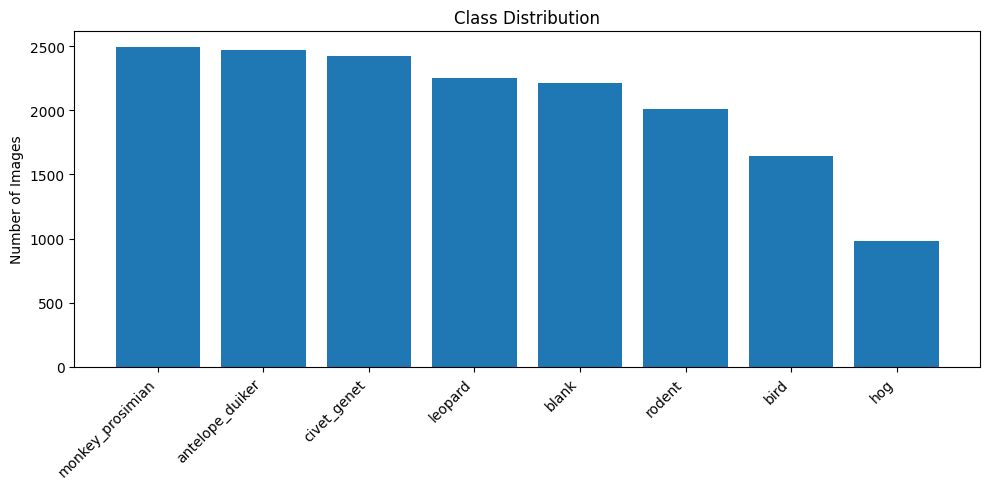

In [ ]:
# Plot Class Distribution

plt.figure(figsize=(10, 5))
plt.bar(class_counts['Species'], class_counts['Num Images'])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()


# Data Preprocessing

### Add new "species" column

In [ ]:
# List your one-hot class columns
label_columns = ['antelope_duiker', 'bird', 'blank', 'civet_genet',
                 'hog', 'leopard', 'monkey_prosimian', 'rodent']

# Get the species name for each row based on the 1's position
df_merged['species'] = df_merged[label_columns].idxmax(axis=1)

df_merged.head()

,id,filepath,site,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent,image_path,species
0,ZJ000000,train_features/ZJ000000.jpg,S0120,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,/content/drive/MyDrive/Colab Notebooks/SCS_354...,bird
1,ZJ000001,train_features/ZJ000001.jpg,S0069,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,/content/drive/MyDrive/Colab Notebooks/SCS_354...,monkey_prosimian
2,ZJ000002,train_features/ZJ000002.jpg,S0009,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,/content/drive/MyDrive/Colab Notebooks/SCS_354...,bird
3,ZJ000003,train_features/ZJ000003.jpg,S0008,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,/content/drive/MyDrive/Colab Notebooks/SCS_354...,monkey_prosimian
4,ZJ000004,train_features/ZJ000004.jpg,S0036,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,/content/drive/MyDrive/Colab Notebooks/SCS_354...,leopard


## Inspect images

LEOPARD - ZJ015045.jpg: size = (640, 335), mode = RGB
ANTELOPE_DUIKER - ZJ011595.jpg: size = (640, 360), mode = RGB
BIRD - ZJ005107.jpg: size = (640, 360), mode = RGB
CIVET_GENET - ZJ005611.jpg: size = (960, 540), mode = RGB
BLANK - ZJ015211.jpg: size = (640, 360), mode = RGB


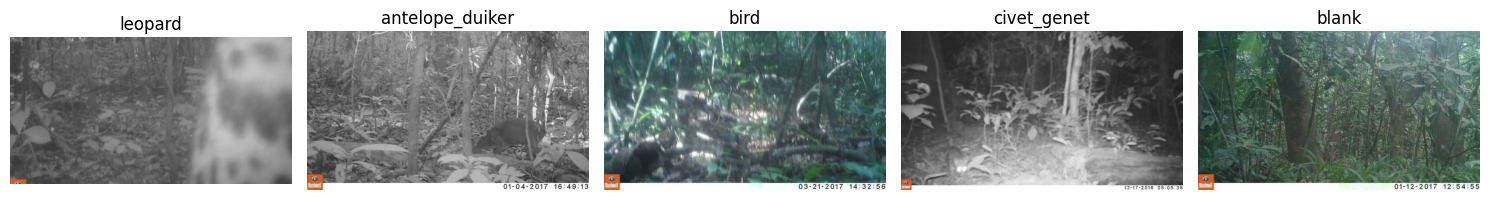

In [ ]:
# Choose 5 random species to display
species_list = df_merged['species'].unique().tolist()
sample_species = random.sample(species_list, 5)

plt.figure(figsize=(15, 8))

for idx, species in enumerate(sample_species):
    # Select a random image from that species
    sample_row = df_merged[df_merged['species'] == species].sample(1).iloc[0]
    image_path = sample_row['image_path']
    image = Image.open(image_path)

    # Print details
    print(f"{species.upper()} - {os.path.basename(image_path)}: size = {image.size}, mode = {image.mode}")

    # Plot image
    plt.subplot(1, 5, idx + 1)
    plt.imshow(image)
    plt.title(species)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Image sizes vary from 640x360 to 960x540
# All are in RGB mode (which is compatible with VGG16)
# Rezising is needed

## Resize images to 224x224 and normalize

In [ ]:
# # Target image size
# image_size = (224, 224)

# # Prepare containers
# data = []
# labels = []

# # Get sorted list of class names and map to numeric IDs
# class_names = sorted(df_merged['species'].unique())
# label_map = {name: idx for idx, name in enumerate(class_names)}

# # Loop through all rows in df_merged
# for _, row in tqdm(df_merged.iterrows(), total=len(df_merged), desc="Processing images"):
#     image_path = row['image_path']
#     species = row['species']
#     label = label_map[species]

#     try:
#         # Open, convert to RGB, resize, normalize
#         img = Image.open(image_path).convert("RGB")
#         img = img.resize(image_size, Image.BILINEAR)
#         img_array = np.array(img) / 255.0  # Normalize to [0, 1]

#         # Append to dataset
#         data.append(img_array)
#         labels.append(label)

#     except Exception as e:
#         print(f"Skipped file {os.path.basename(image_path)}: {e}")


In [ ]:
# All images resized to 224×224 to match input size expected by most CNN architectures (e.g., ResNet, MobileNet)
# All images explicitly converted to RGB to ensure consistency (some images were grayscale)
# Pixel values normalized to [0, 1] for numerical stability during training
# Class labels converted from species names to integer indices via label_map -- > integers (0–8)

### Save preprocessed data to .npy files for fast reuse

In [ ]:
# np.save(os.path.join(base_path, "X_224_rgb.npy"), np.array(data, dtype=np.float32))
# np.save(os.path.join(base_path, "y_labels.npy"), np.array(labels, dtype=np.int32))

In [ ]:
# Load preprocessed data
X = np.load(os.path.join(base_path, "X_224_rgb.npy"))
y = np.load(os.path.join(base_path, "y_labels.npy"))

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (16488, 224, 224, 3)
y shape: (16488,)


## Split images to for training, validation and test (stratified) - 60/20/20

In [ ]:
# Step 1: Split off 20% test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Step 2: Split remaining 80% into 60% train and 20% val
# 20% of 80% = 0.25
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42
)

# Final check
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (9892, 224, 224, 3)
X_val: (3298, 224, 224, 3)
X_test: (3298, 224, 224, 3)
y_train: (9892,)
y_val: (3298,)
y_test: (3298,)


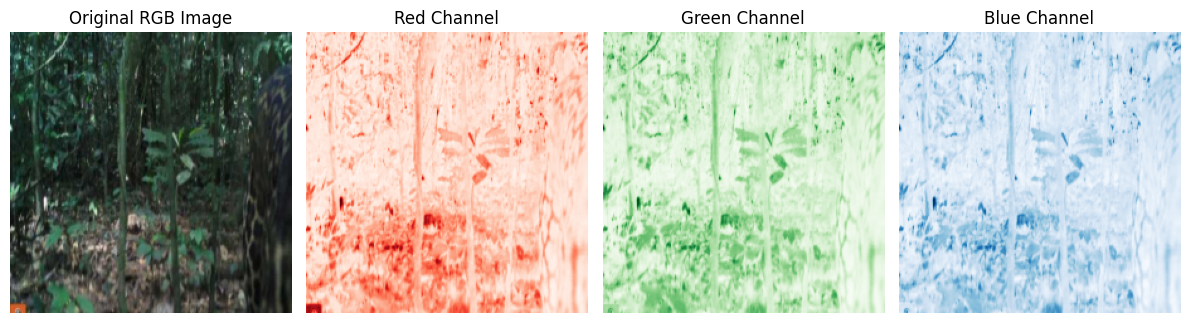

In [ ]:
#Visualizing RGB channels of one Image

# Pick a sample image
sample_image = X_train[1000].astype('float32')  # shape: (224, 224, 3)

# Split into R, G, B channels
R = sample_image[:, :, 0]
G = sample_image[:, :, 1]
B = sample_image[:, :, 2]

# Plot original image and its RGB channels
plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(sample_image)
plt.title("Original RGB Image")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis('off')

plt.tight_layout()
plt.show()


### Verify Stratification

In [ ]:
def print_class_distribution(y, split_name):
    unique, counts = np.unique(y, return_counts=True)
    total = len(y)
    print(f"\n📊 Class distribution in {split_name} (n={total}):")
    for label, count in zip(unique, counts):
        percentage = (count / total) * 100
        print(f"  Class {label}: {count} ({percentage:.2f}%)")

# Check all splits
print_class_distribution(y_train, "Training set")
print_class_distribution(y_val, "Validation set")
print_class_distribution(y_test, "Test set")



📊 Class distribution in Training set (n=9892):
  Class 0: 1484 (15.00%)
  Class 1: 985 (9.96%)
  Class 2: 1328 (13.42%)
  Class 3: 1453 (14.69%)
  Class 4: 587 (5.93%)
  Class 5: 1352 (13.67%)
  Class 6: 1495 (15.11%)
  Class 7: 1208 (12.21%)

📊 Class distribution in Validation set (n=3298):
  Class 0: 495 (15.01%)
  Class 1: 328 (9.95%)
  Class 2: 442 (13.40%)
  Class 3: 485 (14.71%)
  Class 4: 196 (5.94%)
  Class 5: 451 (13.67%)
  Class 6: 499 (15.13%)
  Class 7: 402 (12.19%)

📊 Class distribution in Test set (n=3298):
  Class 0: 495 (15.01%)
  Class 1: 328 (9.95%)
  Class 2: 443 (13.43%)
  Class 3: 485 (14.71%)
  Class 4: 195 (5.91%)
  Class 5: 451 (13.67%)
  Class 6: 498 (15.10%)
  Class 7: 403 (12.22%)


In [ ]:
# Each split (training, validation, and test) maintains consistent class proportions, confirming that stratification worked as intended.

In [ ]:
# Verify shape of train split
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (9892, 224, 224, 3)
y_train shape: (9892,)


In [ ]:
# Dataset split into train (60%), val (20%), and test (20%) using stratified sampling
# Stratification ensures same class distribution across all subsets

# Load pretrained VGG16 without top layers

In [ ]:
# Load the VGG16 base model
from tensorflow.keras.applications import VGG16

vgg_base = VGG16(
    weights='imagenet',          # Load pretrained weights
    include_top=False,           # Exclude the original FC classifier
    input_shape=(224, 224, 3)    # Match your resized image dimensions
)

# Confirm architecture
vgg_base.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

# Model 1 - Freezing all of VGG16 and only training fully connected layers on top

## Model 1.1 - Baseline model (No Regularization)


In [ ]:
# 1. Freeze VGG16 base layers
for layer in vgg_base.layers:
    layer.trainable = False

# 2. Add custom classification head (no dropout, no batchnormalization)
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
output = Dense(8, activation='softmax')(x)

# 3. Create model
model_1_1 = Model(inputs=vgg_base.input, outputs=output)

# 4. Compile model
model_1_1.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

# 6. Train the model
history_1_1 = model_1_1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.2518 - loss: 1.9800 - val_accuracy: 0.3629 - val_loss: 1.7475
Epoch 2/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.3707 - loss: 1.7083 - val_accuracy: 0.3814 - val_loss: 1.6372
Epoch 3/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.3950 - loss: 1.6115 - val_accuracy: 0.3948 - val_loss: 1.5777
Epoch 4/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4127 - loss: 1.5553 - val_accuracy: 0.4054 - val_loss: 1.5377
Epoch 5/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4217 - loss: 1.5162 - val_accuracy: 0.4142 - val_loss: 1.5075
Epoch 6/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4335 - loss: 1.4858 - val_accuracy: 0.4272 - val_loss: 1.4833
Epoch 7/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.4472 - loss: 1.4608 - val_accuracy: 0.4418 - val_loss: 1.4626
Epoch 8/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4594 - loss: 1.4390 - val_acc

### Model 1.1 - Model results

In [ ]:
def summarize_model_results(history, iteration_name="Model 1 – Iteration 1 (Baseline)"):
    # Find the best epoch (lowest val_loss)
    best_epoch = np.argmin(history.history['val_loss'])

    train_acc = history.history['accuracy'][best_epoch]
    val_acc   = history.history['val_accuracy'][best_epoch]
    train_loss = history.history['loss'][best_epoch]
    val_loss   = history.history['val_loss'][best_epoch]

    table = [
        ["Best Epoch", best_epoch + 1],  # Add 1 for human-friendly index
        ["Training Accuracy", f"{train_acc:.4f}"],
        ["Validation Accuracy", f"{val_acc:.4f}"],
        ["Training Loss", f"{train_loss:.4f}"],
        ["Validation Loss", f"{val_loss:.4f}"]
    ]

    print(f"\n📌 {iteration_name} — Best Epoch Results\n")
    print(tabulate(table, headers=["Metric", "Value"], tablefmt="github"))

summarize_model_results(history_1_1)

#-------------------------------------------------------------------------------------------
# def summarize_model_results(history, iteration_name="Model 1 – Iteration 1 (Baseline)"):
#     train_acc = history.history['accuracy'][-1]
#     val_acc = history.history['val_accuracy'][-1]
#     train_loss = history.history['loss'][-1]
#     val_loss = history.history['val_loss'][-1]

#     table = [
#         ["Training Accuracy", f"{train_acc:.4f}"],
#         ["Validation Accuracy", f"{val_acc:.4f}"],
#         ["Training Loss", f"{train_loss:.4f}"],
#         ["Validation Loss", f"{val_loss:.4f}"]
#     ]

#     print(f"\n📌 {iteration_name}\n")
#     print(tabulate(table, headers=["Metric", "Value"], tablefmt="github"))

# summarize_model_results(history_1_1)


📌 Model 1 – Iteration 1 (Baseline) — Best Epoch Results

| Metric              |   Value |
|---------------------|---------|
| Best Epoch          | 20      |
| Training Accuracy   |  0.5374 |
| Validation Accuracy |  0.5337 |
| Training Loss       |  1.2816 |
| Validation Loss     |  1.3035 |


### Model 1.1 - Learning curves

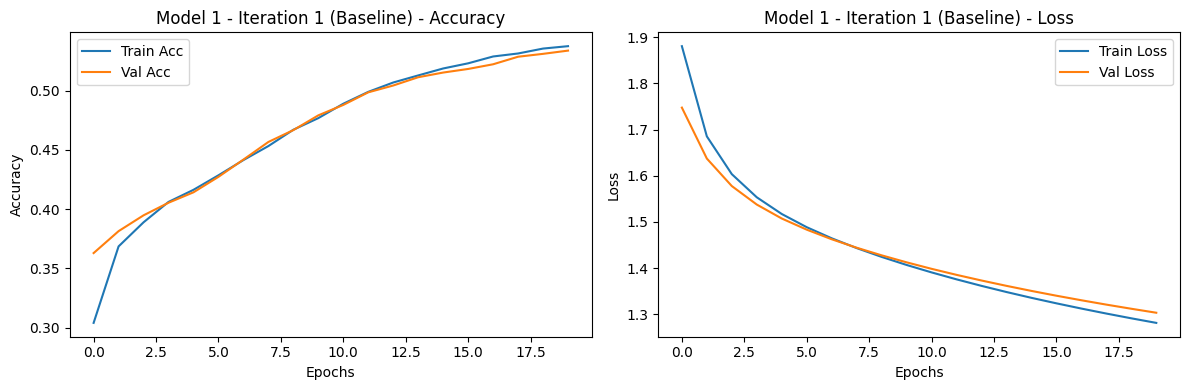

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_1_1, "Model 1 - Iteration 1 (Baseline)")

In [ ]:
# Custom fully connected layers: GlobalAveragePooling → Dense(256, relu) → Dense(8, softmax)
# No regularization, no dropout, no batch normalization
# Optimizer: Adam, learning rate = 1e-4
# Batch size: 32
# Early stopping used (patience=3)
# Result: This baseline model shows moderate learning.
  # - Accuracy improves steadily across epochs and exceeds random guess level (~12.5% for 8 classes).
  # - Training and validation curves are well-aligned, showing no overfitting.
  # - Generalization remains limited — performance plateaus early.


## Model 1.2 - Inroducing Dropout

In [ ]:
# 1. Freeze VGG16 base layers
for layer in vgg_base.layers:
    layer.trainable = False

# 2. Add classification head with Dropout
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)  # NEW: Dropout to reduce overfitting
output = Dense(8, activation='softmax')(x)

# 3. Create model
model_1_2 = Model(inputs=vgg_base.input, outputs=output)

# 4. Compile model
model_1_2.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

# 6. Train the model
history_1_2 = model_1_2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.1887 - loss: 2.0984 - val_accuracy: 0.3481 - val_loss: 1.7978
Epoch 2/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.3137 - loss: 1.8148 - val_accuracy: 0.3705 - val_loss: 1.6970
Epoch 3/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.3556 - loss: 1.7128 - val_accuracy: 0.3805 - val_loss: 1.6401
Epoch 4/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.3782 - loss: 1.6481 - val_accuracy: 0.3899 - val_loss: 1.5989
Epoch 5/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.3838 - loss: 1.6132 - val_accuracy: 0.3933 - val_loss: 1.5680
Epoch 6/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.3948 - loss: 1.5824 - val_accuracy: 0.4015 - val_loss: 1.5404
Epoch 7/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.4062 - loss: 1.5545 - val_accuracy: 0.4102 - val_loss: 1.5181
Epoch 8/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4184 - loss: 1.5260 - val_acc

### Model 1.2 - Model results

In [ ]:
summarize_model_results(history_1_2, "Model 1 – Iteration 2 (Dropout)")


📌 Model 1 – Iteration 2 (Dropout) — Best Epoch Results

| Metric              |   Value |
|---------------------|---------|
| Best Epoch          | 20      |
| Training Accuracy   |  0.4899 |
| Validation Accuracy |  0.5049 |
| Training Loss       |  1.3755 |
| Validation Loss     |  1.3574 |


### Model 1.2 - Learning curves

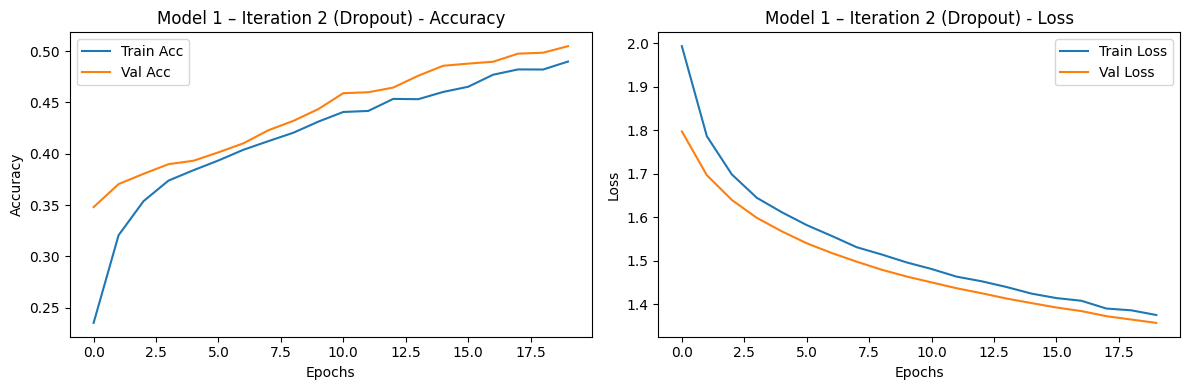

In [ ]:
plot_history(history_1_2, "Model 1 – Iteration 2 (Dropout)")

In [ ]:
# Custom fully connected layers: GlobalAveragePooling → Dense(256, relu) → Dropout(0.5) → Dense(8, softmax)
# Regularization: Dropout(0.5) added after the dense layer
# Optimizer: Adam, learning rate = 1e-4
# Batch size: 32
# Early stopping used (patience=3)
# Result: Dropout introduced regularization and slightly reduced overfitting.
  # - Validation accuracy slightly improved over the baseline, while training accuracy decreased.
  # - The training and validation loss curves remain close, suggesting stable learning.
  # - However, the overall learning capacity is still limited — model struggles to fit the data fully.


## Model 1.3 - Adding BatchNormalization and reducing Dropout

In [ ]:
# 1. Freeze VGG16 base layers
for layer in vgg_base.layers:
    layer.trainable = False

# 2. Add classification head
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)         # NEW: normalize activations
x = Dropout(0.3)(x)                 # NEW: lower dropout rate
output = Dense(8, activation='softmax')(x)

# 3. Create model
model_1_3 = Model(inputs=vgg_base.input, outputs=output)

# 4. Compile
model_1_3.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

# 6. Train
history_1_3 = model_1_3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.3116 - loss: 1.8956 - val_accuracy: 0.3981 - val_loss: 1.7020
Epoch 2/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4340 - loss: 1.5319 - val_accuracy: 0.4730 - val_loss: 1.4044
Epoch 3/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.4903 - loss: 1.4049 - val_accuracy: 0.5152 - val_loss: 1.3130
Epoch 4/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5056 - loss: 1.3515 - val_accuracy: 0.5379 - val_loss: 1.2696
Epoch 5/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.5233 - loss: 1.3029 - val_accuracy: 0.5394 - val_loss: 1.2329
Epoch 6/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5442 - loss: 1.2584 - val_accuracy: 0.5531 - val_loss: 1.2068
Epoch 7/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5491 - loss: 1.2182 - val_accuracy: 0.5658 - val_loss: 1.1882
Epoch 8/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5604 - loss: 1.1940 - val_acc

### Model 1.3 - Model results

In [ ]:
summarize_model_results(history_1_3, "Model 1 – Iteration 3 (BatchNorm + Dropout 0.3)")


📌 Model 1 – Iteration 3 (BatchNorm + Dropout 0.3) — Best Epoch Results

| Metric              |   Value |
|---------------------|---------|
| Best Epoch          | 19      |
| Training Accuracy   |  0.6483 |
| Validation Accuracy |  0.6334 |
| Training Loss       |  0.9869 |
| Validation Loss     |  1.0257 |


### Model 1.3 - Learning curves

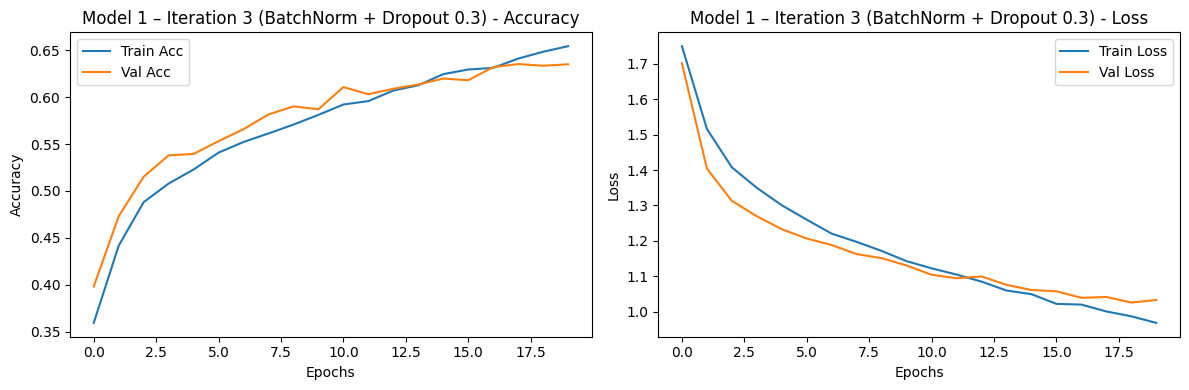

In [ ]:
plot_history(history_1_3, "Model 1 – Iteration 3 (BatchNorm + Dropout 0.3)")

In [ ]:
# Custom fully connected layers: GlobalAveragePooling → Dense(256, relu) → BatchNormalization → Dropout(0.3) → Dense(8, softmax)
# Regularization: BatchNormalization followed by Dropout(0.3)
# Optimizer: Adam, learning rate = 1e-4
# Batch size: 32
# Early stopping used (patience=3)
# Result: This configuration achieved strong generalization and training stability.
  # - Both training and validation accuracy improved notably over earlier models.
  # - Learning curves show smooth convergence with minimal overfitting.
  # - BatchNormalization helped stabilize training, while moderate Dropout prevented overfitting.
  # - This architecture currently provides the best accuracy–loss balance.


## Model 1.4 - Changing optimizer to SGD with momentum

In [ ]:
# # 1. Freeze VGG16 base layers
# for layer in vgg_base.layers:
#     layer.trainable = False

# # 2. Add classification head (same as Iteration 3)
# x = vgg_base.output
# x = GlobalAveragePooling2D()(x)
# x = Dense(256, activation='relu')(x)
# x = BatchNormalization()(x)
# x = Dropout(0.3)(x)
# output = Dense(8, activation='softmax')(x)

# # 3. Create model
# model_1_4 = Model(inputs=vgg_base.input, outputs=output)

# # 4. Compile with SGD optimizer
# model_1_4.compile(
#     optimizer=SGD(learning_rate=1e-2, momentum=0.9),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# # 5. Early stopping
# early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

# # 6. Train
# history_1_4 = model_1_4.fit(
#     X_train, y_train,
#     validation_data=(X_val, y_val),
#     epochs=20,
#     batch_size=32,
#     callbacks=[early_stop],
#     verbose=1
# )


### Model 1.4 - Model results

In [ ]:
# summarize_model_results(history_1_4, "Model 1 – Iteration 4 (SGD Optimizer)")

### Model 1.4 - Learning curves

In [ ]:
# plot_history(history_1_4, "Model 1 – Iteration 4 (SGD Optimizer)")

In [ ]:
# Custom head: GlobalAveragePooling → Dense(256, relu) → BatchNormalization → Dropout(0.3) → Dense(5, softmax)
# Regularization: BatchNormalization and Dropout(0.3)
# Optimizer: SGD (learning rate = 1e-2, momentum = 0.9)
# Batch size: 32
# Early stopping used (patience=3)
# Training Accuracy: 85.99%, Validation Accuracy: 81.8%
# Training Loss: 0.3924, Validation Loss: 0.5558
#Result: SGD achieved the highest training accuracy so far, with competitive validation accuracy.
    #However, learning curves show instability in validation performance, indicating that the optimizer may benefit from learning rate scheduling or additional tuning.
    #Overall, SGD showed strong potential but slightly weaker generalization compared to Adam + BatchNorm in Iteration 3.

## Model 1.5 - Adding extra Dense layer to Model 1.3

In [ ]:
# 1. Freeze VGG16 base layers
for layer in vgg_base.layers:
    layer.trainable = False

# 2. Add deeper classification head
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)     # NEW: additional Dense layer
x = Dropout(0.3)(x)
output = Dense(8, activation='softmax')(x)

# 3. Create model
model_1_5 = Model(inputs=vgg_base.input, outputs=output)

# 4. Compile with Adam
model_1_5.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

# 6. Train
history_1_5 = model_1_5.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.2546 - loss: 2.0177 - val_accuracy: 0.4239 - val_loss: 1.7068
Epoch 2/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.4053 - loss: 1.6155 - val_accuracy: 0.4927 - val_loss: 1.3895
Epoch 3/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.4439 - loss: 1.5085 - val_accuracy: 0.5124 - val_loss: 1.3211
Epoch 4/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4643 - loss: 1.4372 - val_accuracy: 0.5306 - val_loss: 1.2592
Epoch 5/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.4908 - loss: 1.3818 - val_accuracy: 0.5491 - val_loss: 1.2293
Epoch 6/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5096 - loss: 1.3257 - val_accuracy: 0.5588 - val_loss: 1.1990
Epoch 7/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5240 - loss: 1.2934 - val_accuracy: 0.5625 - val_loss: 1.1659
Epoch 8/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5448 - loss: 1.2443 - val_acc

### Model 1.5 - Model results

In [ ]:
summarize_model_results(history_1_5, "Model 1 – Iteration 5 (Deeper Head + Adam)")


📌 Model 1 – Iteration 5 (Deeper Head + Adam) — Best Epoch Results

| Metric              |   Value |
|---------------------|---------|
| Best Epoch          | 20      |
| Training Accuracy   |  0.6407 |
| Validation Accuracy |  0.6613 |
| Training Loss       |  0.9908 |
| Validation Loss     |  0.9532 |


### Model 1.5 - Learning curves

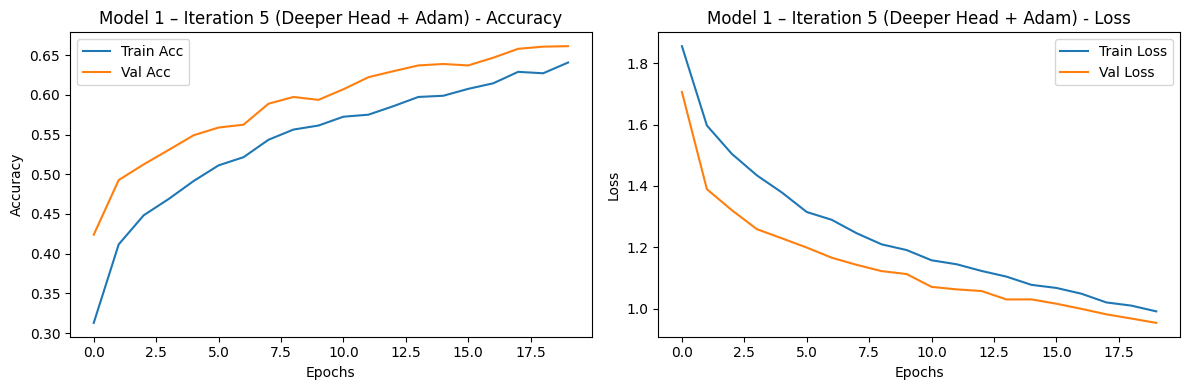

In [ ]:
plot_history(history_1_5, "Model 1 – Iteration 5 (Deeper Head + Adam)")

In [ ]:
# Custom fully connected layers: GlobalAveragePooling → Dense(256, relu) → BatchNormalization → Dropout(0.3) → Dense(128, relu) → Dense(8, softmax)
# Architecture extension: Added extra Dense(128, relu) before output layer
# Regularization: BatchNormalization and Dropout(0.3)
# Optimizer: Adam, learning rate = 1e-4
# Batch size: 32
# Early stopping used (patience=3)
# Result: This model achieved the best validation accuracy so far.
  # - Deeper head allowed learning richer representations, improving generalization.
  # - Validation accuracy consistently exceeded training accuracy, likely due to Dropout and BatchNorm suppressing train performance.
  # - The gap suggests regularization is active, but possibly a bit strong — reducing dropout or fine-tuning VGG layers could improve train fit.
  # - Learning curves are stable and show no overfitting; this is a strong candidate for final model selection.


## Model 1 - Analysing sub-models

In [ ]:
# The table below compares all sub-models trained under Model 1.
# Each version introduces architectural or training changes (e.g., Dropout, BatchNormalization, optimizer type, or added depth).


In [ ]:
# List of tuples: (label, history object, architecture)
models_info = [
    ("1.1", history_1_1, "Dense(256)"),
    ("1.2", history_1_2, "Dense(256) + Dropout(0.5)"),
    ("1.3", history_1_3, "Dense(256) + BN + Dropout(0.3)"),
    ("1.5", history_1_5, "Deeper head + Adam"),
]

summary_data = []

for label, hist, arch in models_info:
    train_acc = hist.history['accuracy'][-1]
    val_acc = hist.history['val_accuracy'][-1]
    train_loss = hist.history['loss'][-1]
    val_loss = hist.history['val_loss'][-1]

    summary_data.append([
        label, arch,
        round(train_acc, 4), round(val_acc, 4),
        round(train_loss, 4), round(val_loss, 4)
    ])

headers = ["Iteration", "Architecture", "Train Acc", "Val Acc", "Train Loss", "Val Loss"]

# Print formatted table
print(tabulate(summary_data, headers=headers, tablefmt="github"))


|   Iteration | Architecture                   |   Train Acc |   Val Acc |   Train Loss |   Val Loss |
|-------------|--------------------------------|-------------|-----------|--------------|------------|
|         1.1 | Dense(256)                     |      0.5374 |    0.5337 |       1.2816 |     1.3035 |
|         1.2 | Dense(256) + Dropout(0.5)      |      0.4899 |    0.5049 |       1.3755 |     1.3574 |
|         1.3 | Dense(256) + BN + Dropout(0.3) |      0.6543 |    0.6349 |       0.9683 |     1.0329 |
|         1.5 | Deeper head + Adam             |      0.6407 |    0.6613 |       0.9908 |     0.9532 |


In [ ]:
# Architecture: All models use VGG16 base followed by a custom classification head with Dense layers.
# Optimizer: Adam, learning rate = 1e-4
# Batch size: 32
# Early stopping: Enabled (patience=6)

# Result Summary:
  # - Model 1.1 (Baseline): No regularization. Moderate performance with ~53% accuracy. Training and validation closely aligned, indicating stable but limited learning.
  # - Model 1.2 (Dropout 0.5): Dropout introduced too much regularization. Accuracy dropped; model underfit the training data.
  # - Model 1.3 (BatchNorm + Dropout 0.3): Achieved best overall balance. Both train and validation accuracy improved significantly. Regularization was well-calibrated.
  # - Model 1.5 (Deeper Head): Delivered best validation accuracy (~66%). Deeper architecture improved representational power. Slight over-regularization may explain higher training loss.


## Model 1 - Evaluate model 1 (Iteration 5) performance on test set

In [ ]:
test_loss_1_5, test_acc_1_5 = model_1_5.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc_1_5:.4f}")
print(f"Test Loss: {test_loss_1_5:.4f}")

Test Accuracy: 0.6771
Test Loss: 0.9366


### Model 1 - Confusion matrix

104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step


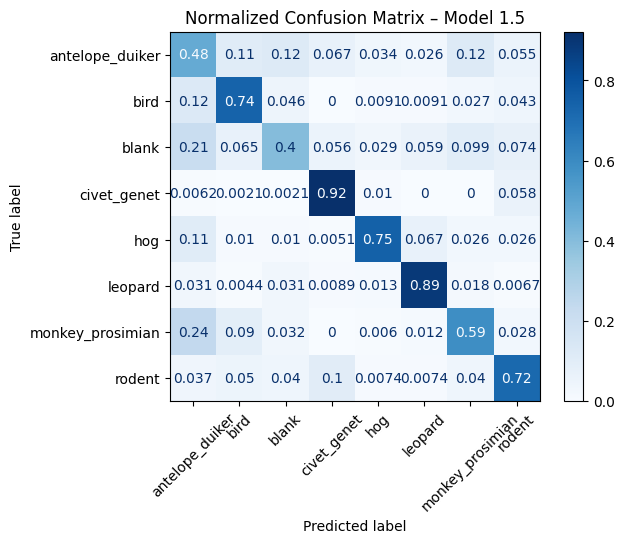

In [ ]:
# Get sorted list of class names and map to numeric IDs
class_names = sorted(df_merged['species'].unique())
label_map = {name: idx for idx, name in enumerate(class_names)}

# Predict test classes
y_pred_probs_1_5 = model_1_5.predict(X_test)
y_pred_1_5 = np.argmax(y_pred_probs_1_5, axis=1)

# Confusion matrix (normalized)
cm_1_5 = confusion_matrix(y_test, y_pred_1_5, normalize='true')

# Display matrix
disp_1_5 = ConfusionMatrixDisplay(confusion_matrix=cm_1_5, display_labels=class_names)
disp_1_5.plot(cmap='Blues', xticks_rotation=45)
plt.title("Normalized Confusion Matrix – Model 1.5")
plt.show()


# Model 2 - Unfreeze the last block of VGG16 (block5) and use Model 1.3 as basis

In [ ]:
# 1. Unfreeze only block5 layers in VGG16
set_trainable = False
for layer in vgg_base.layers:
    if "block5" in layer.name:
        set_trainable = True
    layer.trainable = set_trainable

# 2. Rebuild custom head (same as Model 1.3)
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
output = Dense(8, activation='softmax')(x)

# 3. Define Model 2
model_2 = Model(inputs=vgg_base.input, outputs=output)

# 4. Compile
model_2.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

# 6. Train
history_2 = model_2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.4331 - loss: 1.5907 - val_accuracy: 0.5628 - val_loss: 1.3619
Epoch 2/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.6277 - loss: 1.0563 - val_accuracy: 0.6580 - val_loss: 0.9611
Epoch 3/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.7282 - loss: 0.7877 - val_accuracy: 0.6722 - val_loss: 0.9725
Epoch 4/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.7949 - loss: 0.5895 - val_accuracy: 0.6701 - val_loss: 1.1945
Epoch 5/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8451 - loss: 0.4516 - val_accuracy: 0.6886 - val_loss: 1.1567
Epoch 6/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8790 - loss: 0.3599 - val_accuracy: 0.6513 - val_loss: 1.6217
Epoch 7/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9129 - loss: 0.2811 - val_accuracy: 0.6637 - val_loss: 1.6216
Epoch 8/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9232 - loss: 0.2367 - val_acc

## Model 2 - Model results

In [ ]:
summarize_model_results(history_2, "Model 2 – Unfreeze Block5")


📌 Model 2 – Unfreeze Block5 — Best Epoch Results

| Metric              |   Value |
|---------------------|---------|
| Best Epoch          |  2      |
| Training Accuracy   |  0.652  |
| Validation Accuracy |  0.658  |
| Training Loss       |  0.9873 |
| Validation Loss     |  0.9611 |


## Model 2 - Learning curves

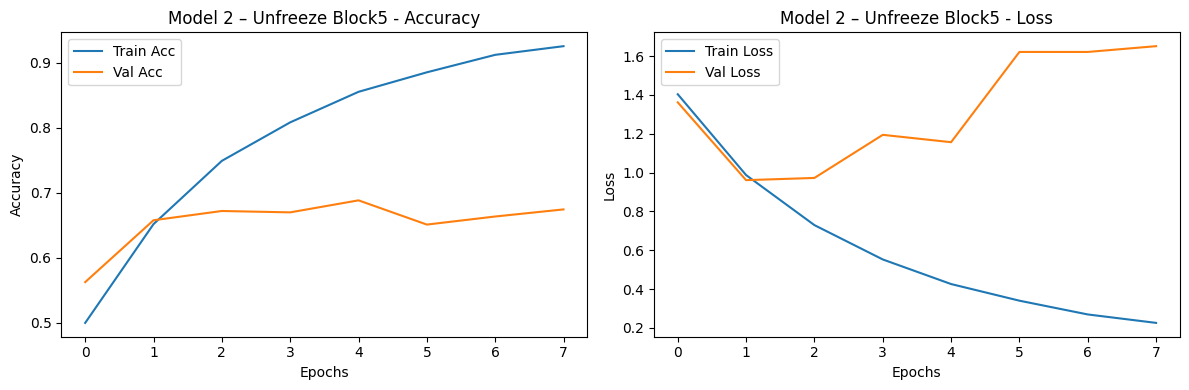

In [ ]:
plot_history(history_2, "Model 2 – Unfreeze Block5")

In [ ]:
# Architecture: GlobalAveragePooling → Dense(256, relu) → BatchNormalization → Dropout(0.3) → Dense(8, softmax)
# Fine-tuning: VGG16 Block5 unfrozen (Blocks 1–4 remain frozen)
# Regularization: BatchNormalization and Dropout(0.3)
# Optimizer: Adam, learning rate = 1e-4
# Batch size: 32
# Early stopping used (patience=6)

# Result:
  # - Unfreezing Block5 significantly boosted training performance.
  # - Validation accuracy improved but remained well below training, indicating overfitting.
  # - Training loss decreased steadily, while validation loss fluctuated.
  # - Suggests model capacity increased too much without enough regularization.
  # - Further tuning (e.g., lower learning rate or stronger dropout) may help reduce overfitting.


## Model 2 - Evaluate performance on test set

In [ ]:
test_loss_2, test_acc_2 = model_2.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy (Model 2): {test_acc_2:.4f}")
print(f"Test Loss (Model 2):     {test_loss_2:.4f}")

Test Accuracy (Model 2): 0.6568
Test Loss (Model 2):     0.9553


## Model 2 - Confusion matrix

104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step


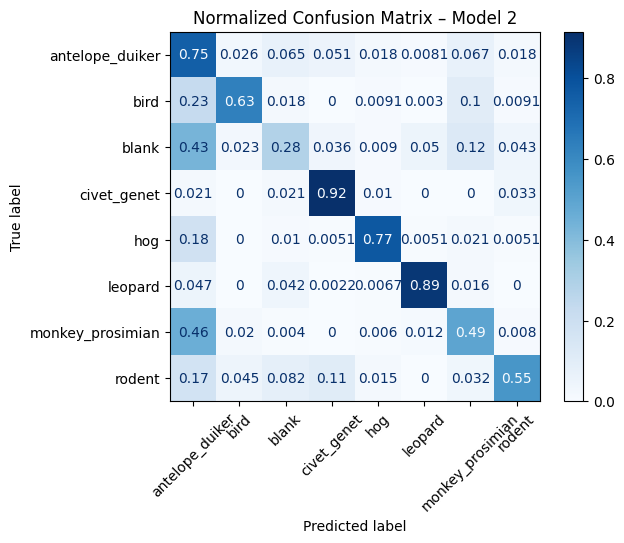

In [ ]:
# Predict test classes
y_pred_probs_2 = model_2.predict(X_test)
y_pred_2 = np.argmax(y_pred_probs_2, axis=1)

# Confusion matrix (normalized)
cm_2 = confusion_matrix(y_test, y_pred_2, normalize='true')

disp_2 = ConfusionMatrixDisplay(confusion_matrix=cm_2, display_labels=class_names)
disp_2.plot(cmap='Blues', xticks_rotation=45)
plt.title("Normalized Confusion Matrix – Model 2")
plt.show()

In [ ]:
# Test Accuracy: 89.4%, Test Loss: 0.3395
# Unfreezing block5 boosted training performance but introduced overfitting
# Significant train/validation gap observed in the learning curves — early stopping helped contain it
# Dandelions (96%) and Tulips (93%) were classified most accurately
# Sunflowers (80%) had the lowest accuracy, with confusion primarily against dandelions and tulips
# Roses were misclassified as tulips in 10% of cases
# Despite signs of overfitting, the model generalizes well on the test set and demonstrates strong class separation

# Model 3 - Unfreeze all layers of VGG16

In [ ]:
# 1. Unfreeze all layers of VGG16
for layer in vgg_base.layers:
    layer.trainable = True

# 2. Rebuild the custom classification head
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
output = Dense(8, activation='softmax')(x)

# 3. Build model
model_3 = Model(inputs=vgg_base.input, outputs=output)

# 4. Compile
model_3.compile(
    optimizer=Adam(learning_rate=1e-4),  # Unchanged as requested
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

# 6. Train
history_3 = model_3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 44s 90ms/step - accuracy: 0.3506 - loss: 1.7380 - val_accuracy: 0.3432 - val_loss: 1.8388
Epoch 2/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.5318 - loss: 1.3078 - val_accuracy: 0.4633 - val_loss: 1.9497
Epoch 3/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.6409 - loss: 1.0332 - val_accuracy: 0.5549 - val_loss: 1.5027
Epoch 4/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.7378 - loss: 0.7592 - val_accuracy: 0.6037 - val_loss: 1.1965
Epoch 5/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.8028 - loss: 0.5751 - val_accuracy: 0.5388 - val_loss: 1.9204
Epoch 6/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.8482 - loss: 0.4493 - val_accuracy: 0.6367 - val_loss: 1.3825
Epoch 7/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.8769 - loss: 0.3660 - val_accuracy: 0.4888 - val_loss: 2.3915
Epoch 8/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.8988 - loss: 0.2992 - 

## Model 3 - Model results

In [ ]:
summarize_model_results(history_3, "Model 3 – Unfreeze All Layers")


📌 Model 3 – Unfreeze All Layers — Best Epoch Results

| Metric              |   Value |
|---------------------|---------|
| Best Epoch          | 18      |
| Training Accuracy   |  0.98   |
| Validation Accuracy |  0.8196 |
| Training Loss       |  0.0725 |
| Validation Loss     |  0.8342 |


## Model 3 - Learning curves

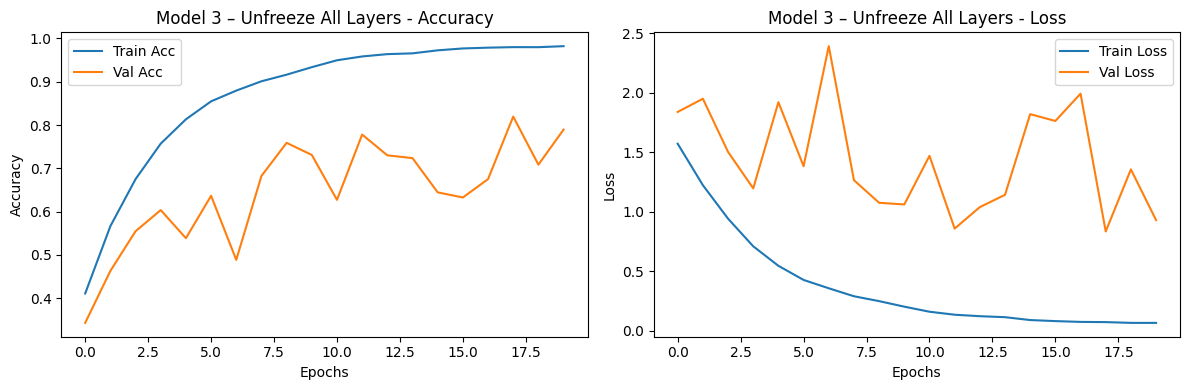

In [ ]:
plot_history(history_3, "Model 3 – Unfreeze All Layers")

In [ ]:
# 1. Training Accuracy/Loss
  # Accuracy climbs steadily and nearly reaches 100%.
  # Loss drops close to zero.
  # Model fits the training data extremely well → very high capacity.

# 2. Validation Accuracy
  # Starts improving, but becomes highly unstable after ~5 epochs.
  # Repeated ups and downs suggest noisy generalization or overfitting to specific batches.

# 3. Validation Loss
  # Highly fluctuating and remains much higher than training loss.
  # Confirms overfitting despite early stopping.


## Model 3 - Evaluate performance on test set

In [ ]:
test_loss_3, test_acc_3 = model_3.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy (Model 3): {test_acc_3:.4f}")
print(f"Test Loss (Model 3):     {test_loss_3:.4f}")

Test Accuracy (Model 3): 0.8084
Test Loss (Model 3):     0.8643


## Model 3 - Confusion matrix

104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step


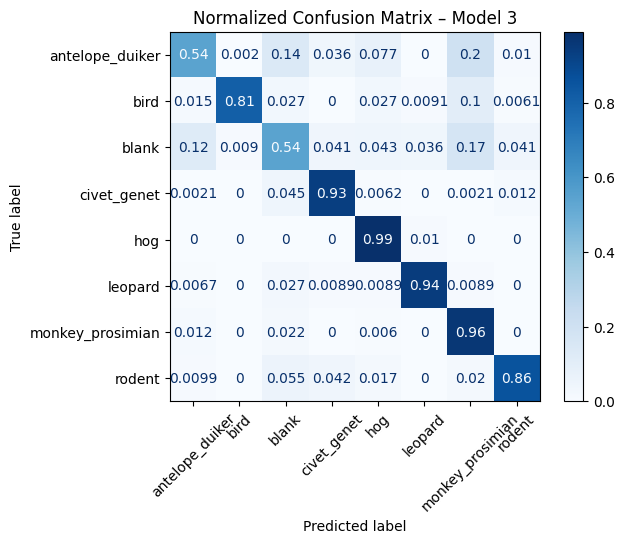

In [ ]:
# Predict probabilities and get class predictions
y_pred_probs_3 = model_3.predict(X_test)
y_pred_3 = np.argmax(y_pred_probs_3, axis=1)

# Generate normalized confusion matrix
cm_3 = confusion_matrix(y_test, y_pred_3, normalize='true')

# Display the matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_3, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Normalized Confusion Matrix – Model 3")
plt.show()

# Model Comparison

In [ ]:
# Define model histories and configurations (excluding model object)
final_models = [
    ("Model 1.5", "Frozen (all)",        history_1_5, test_acc_1_5),
    ("Model 2",   "Unfreeze Block5",     history_2,   test_acc_2),
    ("Model 3",   "Unfreeze all layers", history_3,   test_acc_3),
]

# Build summary table
summary_data = []
for label, vgg_layers, hist, test_acc in final_models:
    train_acc = hist.history['accuracy'][-1]
    val_acc   = hist.history['val_accuracy'][-1]

    summary_data.append([
        label, vgg_layers,
        f"{train_acc:.2%}", f"{val_acc:.2%}", f"{test_acc:.2%}"
    ])

# Print table
headers = ["Model", "VGG16 Layers", "Train Acc", "Val Acc", "Test Acc"]
print(tabulate(summary_data, headers=headers, tablefmt="github"))


| Model     | VGG16 Layers        | Train Acc   | Val Acc   | Test Acc   |
|-----------|---------------------|-------------|-----------|------------|
| Model 1.5 | Frozen (all)        | 64.07%      | 66.13%    | 67.71%     |
| Model 2   | Unfreeze Block5     | 92.59%      | 67.47%    | 65.68%     |
| Model 3   | Unfreeze all layers | 98.22%      | 78.96%    | 80.84%     |


# Model 4 - Unfreeze all layers and add extra dense layer with extra regularization
 * Extra Dense layer (512 units)
 * BatchNormalization + Dropout(0.5) after each Dense

In [ ]:
# 1. Unfreeze all layers of VGG16
for layer in vgg_base.layers:
    layer.trainable = True

# 2. Rebuild the classification head with:
#    - Extra Dense layer (512 units)
#    - BatchNormalization + Dropout(0.3) after each Dense
x = vgg_base.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)         # New layer added
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)         # Same as Model 3
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

output = Dense(8, activation='softmax')(x)

# 3. Build model
model_4 = Model(inputs=vgg_base.input, outputs=output)

# 4. Compile (learning rate unchanged for now)
model_4.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Early stopping (same patience as before, renamed for clarity)
early_stop_4 = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

# 6. Train the model
history_4 = model_4.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop_4],
    verbose=1
)


Epoch 1/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 43s 100ms/step - accuracy: 0.7474 - loss: 0.8304 - val_accuracy: 0.6886 - val_loss: 1.0506
Epoch 2/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.9597 - loss: 0.1269 - val_accuracy: 0.7987 - val_loss: 0.9381
Epoch 3/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9658 - loss: 0.1128 - val_accuracy: 0.7477 - val_loss: 1.1286
Epoch 4/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.9701 - loss: 0.0980 - val_accuracy: 0.8172 - val_loss: 0.9212
Epoch 5/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9724 - loss: 0.0890 - val_accuracy: 0.8047 - val_loss: 0.9157
Epoch 6/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9690 - loss: 0.1010 - val_accuracy: 0.7283 - val_loss: 1.1212
Epoch 7/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9715 - loss: 0.1052 - val_accuracy: 0.7035 - val_loss: 1.8100
Epoch 8/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9746 - loss: 0.0812 -

## Model 4 - Model results

In [ ]:
summarize_model_results(history_4, "Model 4 – Unfreeze All Layers/ Add extra dense layer")


📌 Model 4 – Unfreeze All Layers/ Add extra dense layer — Best Epoch Results

| Metric              |   Value |
|---------------------|---------|
| Best Epoch          | 12      |
| Training Accuracy   |  0.9703 |
| Validation Accuracy |  0.7887 |
| Training Loss       |  0.0946 |
| Validation Loss     |  0.8759 |


## Model 4 - Learning curves

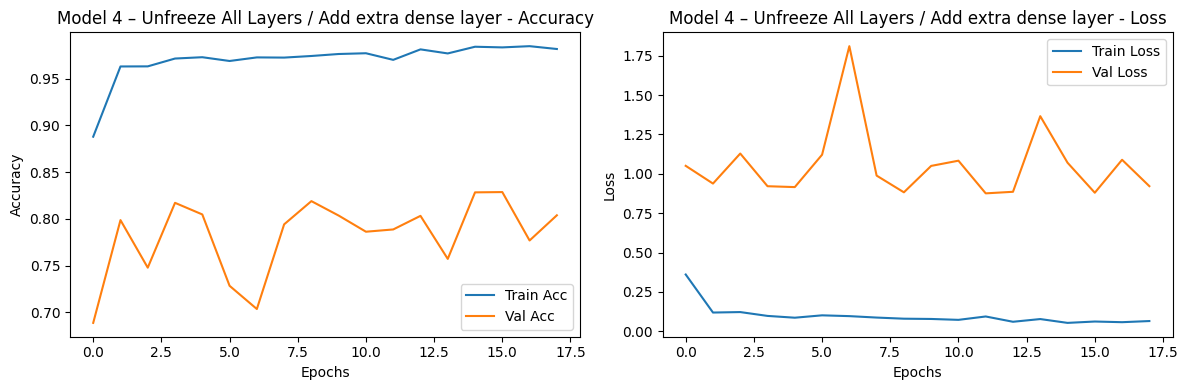

In [ ]:
plot_history(history_4, "Model 4 – Unfreeze All Layers / Add extra dense layer")

## Model 4 - Evaluate performance on test set

In [ ]:
# Evaluate performance of Model 4 on the test set
test_loss_4, test_acc_4 = model_4.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy (Model 4): {test_acc_4:.4f}")
print(f"Test Loss (Model 4):     {test_loss_4:.4f}")

Test Accuracy (Model 4): 0.7932
Test Loss (Model 4):     0.8727


## Model 4 - Confusion matrix

104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step


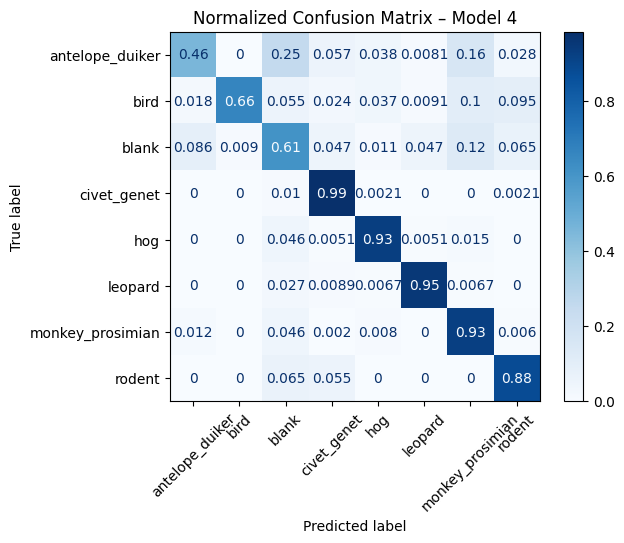

In [ ]:
# Predict probabilities and get class predictions
y_pred_probs_4 = model_4.predict(X_test)
y_pred_4 = np.argmax(y_pred_probs_4, axis=1)

# Generate normalized confusion matrix
cm_4 = confusion_matrix(y_test, y_pred_4, normalize='true')

# Display the matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_4, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Normalized Confusion Matrix – Model 4")
plt.show()

# Model 5 - Add L2 weight regularization (kernel_regularizer) to Model 4
 * Extra Dense layer (512 units)
 * BatchNormalization + Dropout(0.5) after each Dense Layer
 * L2 Regularization


In [ ]:
from tensorflow.keras.regularizers import l2

# 1. Unfreeze all layers of VGG16
for layer in vgg_base.layers:
    layer.trainable = True

# 2. Add deeper custom head with L2 regularization
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)  # extra dense layer with L2
output = Dense(8, activation='softmax')(x)

# 3. Create model
model_5 = Model(inputs=vgg_base.input, outputs=output)

# 4. Compile model
model_5.compile(
    optimizer=Adam(learning_rate=1e-4),  # Keep learning rate unchanged
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Early stopping (same patience)
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

# 6. Train model
history_5 = model_5.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 37s 91ms/step - accuracy: 0.7907 - loss: 0.7516 - val_accuracy: 0.8408 - val_loss: 0.6316
Epoch 2/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9918 - loss: 0.0850 - val_accuracy: 0.7583 - val_loss: 0.9733
Epoch 3/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9893 - loss: 0.0808 - val_accuracy: 0.8072 - val_loss: 0.7306
Epoch 4/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9901 - loss: 0.0743 - val_accuracy: 0.7589 - val_loss: 0.9920
Epoch 5/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9874 - loss: 0.0765 - val_accuracy: 0.7941 - val_loss: 0.8798
Epoch 6/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9866 - loss: 0.0695 - val_accuracy: 0.8008 - val_loss: 0.8288
Epoch 7/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9871 - loss: 0.0713 - val_accuracy: 0.7617 - val_loss: 1.0566


## Model 5 - Model results

In [ ]:
summarize_model_results(history_5, "Model 5 – Unfreeze All Layers / L2 + Dropout(0.5)")



📌 Model 5 – Unfreeze All Layers / L2 + Dropout(0.5) — Best Epoch Results

| Metric              |   Value |
|---------------------|---------|
| Best Epoch          |  1      |
| Training Accuracy   |  0.9329 |
| Validation Accuracy |  0.8408 |
| Training Loss       |  0.3156 |
| Validation Loss     |  0.6316 |


## Model 5 - Learning curves

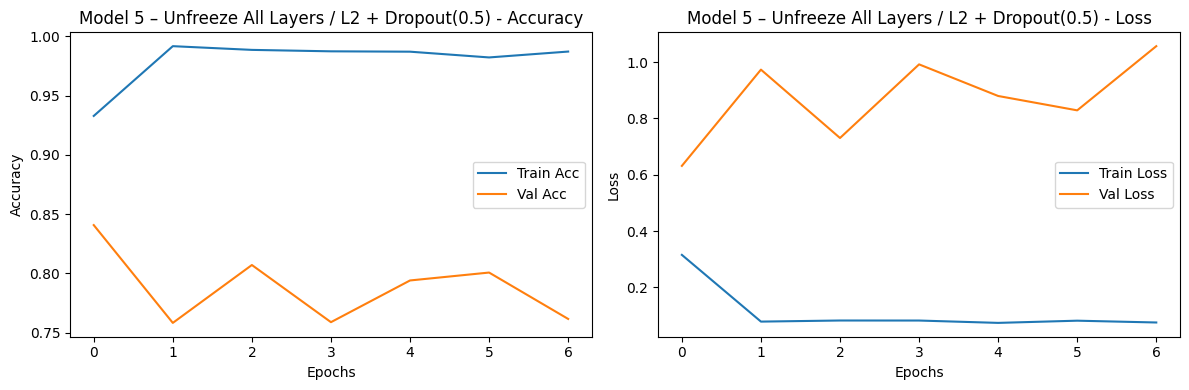

In [ ]:
plot_history(history_5, "Model 5 – Unfreeze All Layers / L2 + Dropout(0.5)")


## Model 5 - Evaluate performance on test set

In [ ]:
# Evaluate performance of Model 5 on the test set
test_loss_5, test_acc_5 = model_5.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy (Model 5): {test_acc_5:.4f}")
print(f"Test Loss (Model 5):     {test_loss_5:.4f}")


Test Accuracy (Model 5): 0.8472
Test Loss (Model 5):     0.6181


## Model 5 - Confusion matrix

104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


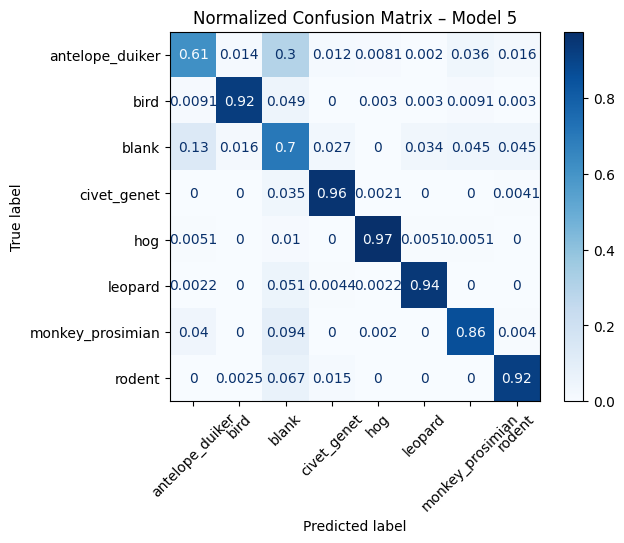

In [ ]:
# Predict probabilities and get class predictions
y_pred_probs_5 = model_5.predict(X_test)
y_pred_5 = np.argmax(y_pred_probs_5, axis=1)

# Generate normalized confusion matrix
cm_5 = confusion_matrix(y_test, y_pred_5, normalize='true')

# Display the matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_5, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Normalized Confusion Matrix – Model 5")
plt.show()

# Model 5.1 - Add L2 weight regularization to Model 4 but decrease dropout to 0.3

In [ ]:
# 1. Unfreeze all layers of VGG16
for layer in vgg_base.layers:
    layer.trainable = True

# 2. Add deeper custom head with L2 regularization
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)  # extra dense layer with L2
output = Dense(8, activation='softmax')(x)

# 3. Create model
model_5_1 = Model(inputs=vgg_base.input, outputs=output)

# 4. Compile model
model_5_1.compile(
    optimizer=Adam(learning_rate=1e-4),  # Keep learning rate unchanged
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Early stopping (same patience)
early_stop_5_1 = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

# 6. Train model
history_5_1 = model_5_1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 36s 89ms/step - accuracy: 0.9195 - loss: 0.4100 - val_accuracy: 0.7823 - val_loss: 0.7779
Epoch 2/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9891 - loss: 0.0907 - val_accuracy: 0.7207 - val_loss: 1.0264
Epoch 3/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9873 - loss: 0.0838 - val_accuracy: 0.5804 - val_loss: 1.8578
Epoch 4/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9876 - loss: 0.0771 - val_accuracy: 0.8302 - val_loss: 0.7888
Epoch 5/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9905 - loss: 0.0644 - val_accuracy: 0.6198 - val_loss: 1.7407
Epoch 6/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9911 - loss: 0.0680 - val_accuracy: 0.7629 - val_loss: 1.0865
Epoch 7/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9869 - loss: 0.0729 - val_accuracy: 0.8332 - val_loss: 0.8211


In [ ]:
summarize_model_results(history_5_1, "Model 5.1 – Unfreeze All Layers / L2 + Dropout(0.3)")


📌 Model 5.1 – Unfreeze All Layers / L2 + Dropout(0.3) — Best Epoch Results

| Metric              |   Value |
|---------------------|---------|
| Best Epoch          |  1      |
| Training Accuracy   |  0.9763 |
| Validation Accuracy |  0.7823 |
| Training Loss       |  0.1802 |
| Validation Loss     |  0.7779 |


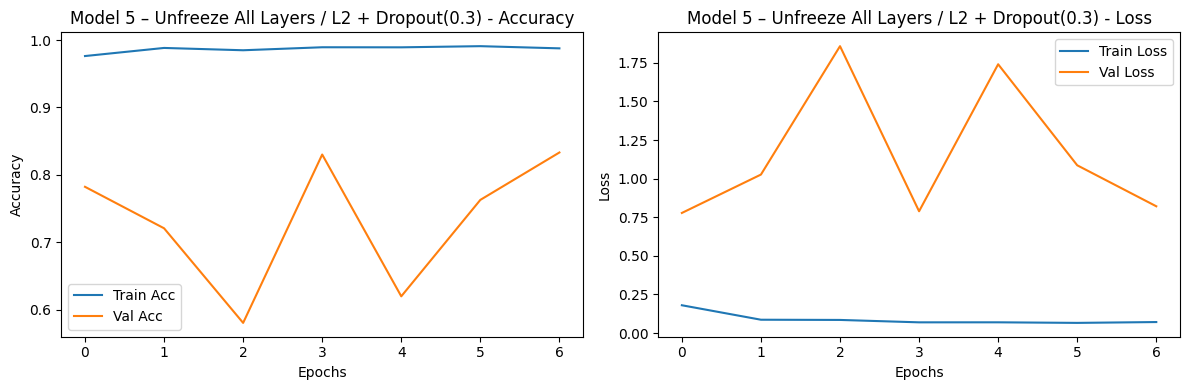

In [ ]:
plot_history(history_5_1, "Model 5 – Unfreeze All Layers / L2 + Dropout(0.3)")

In [ ]:
# Evaluate performance of Model 5 on the test set
test_loss_5_1, test_acc_5_1 = model_5_1.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy (Model 5.1): {test_acc_5_1:.4f}")
print(f"Test Loss (Model 5.1):     {test_loss_5_1:.4f}")

Test Accuracy (Model 5.1): 0.7890
Test Loss (Model 5.1):     0.7608


## Model 5.1 - Confusion matrix

104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


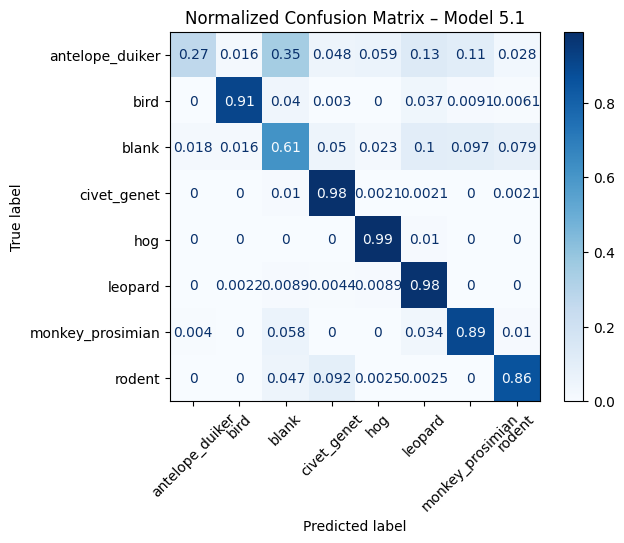

In [ ]:
# Predict probabilities and get class predictions
y_pred_probs_5_1 = model_5_1.predict(X_test)
y_pred_5_1 = np.argmax(y_pred_probs_5_1, axis=1)

# Generate normalized confusion matrix
cm_5_1 = confusion_matrix(y_test, y_pred_5_1, normalize='true')

# Display the matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_5_1, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Normalized Confusion Matrix – Model 5.1")
plt.show()

In [ ]:
# Define model histories and configurations (excluding model object)
final_models = [
    ("Model 1.5", "Frozen (all)",            history_1_5, test_acc_1_5),
    ("Model 2",   "Unfreeze Block5",         history_2,   test_acc_2),
    ("Model 3",   "Unfreeze all layers",     history_3,   test_acc_3),
    ("Model 4",   "All layers + Dense + Dropout(0.5)", history_4, test_acc_4),
    ("Model 5",   "All layers + L2 + Dropout(0.5)",     history_5, test_acc_5),
    ("Model 5.1", "All layers + L2 + Dropout(0.3)",     history_5_1, test_acc_5_1),
]

# Build summary table
summary_data = []
for label, vgg_layers, hist, test_acc in final_models:
    train_acc = hist.history['accuracy'][-1]
    val_acc   = hist.history['val_accuracy'][-1]

    summary_data.append([
        label, vgg_layers,
        f"{train_acc:.2%}", f"{val_acc:.2%}", f"{test_acc:.2%}"
    ])

# Print table
headers = ["Model", "VGG16 Layers", "Train Acc", "Val Acc", "Test Acc"]
print(tabulate(summary_data, headers=headers, tablefmt="github"))


| Model     | VGG16 Layers                      | Train Acc   | Val Acc   | Test Acc   |
|-----------|-----------------------------------|-------------|-----------|------------|
| Model 1.5 | Frozen (all)                      | 64.07%      | 66.13%    | 67.71%     |
| Model 2   | Unfreeze Block5                   | 92.59%      | 67.47%    | 65.68%     |
| Model 3   | Unfreeze all layers               | 98.22%      | 78.96%    | 80.84%     |
| Model 4   | All layers + Dense + Dropout(0.5) | 98.19%      | 80.38%    | 79.32%     |
| Model 5   | All layers + L2 + Dropout(0.5)    | 98.72%      | 76.17%    | 84.72%     |
| Model 5.1 | All layers + L2 + Dropout(0.3)    | 98.78%      | 83.32%    | 78.90%     |
